
## 1)  Loading Libraries & Dataset
#

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from IPython.display import display  # print() can only print text , for tabular multiple tabular 
                                     # dataframes to print in a single cell we use display()

import warnings 
warnings.filterwarnings('ignore') # as some functions maybe depricated in future versions to ignore the 
                                  # messages of these updates we ignore them}

In [6]:
df = pd.read_csv('../data/raw/heart.csv')
display(df.head())

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


#
# 2) Exploratory Data Analysis 
#

###
### 2.1 - Basic Inspection : Duplicates / Null Values / Shape 
###

In [10]:
display(df.columns) # columns is an attribute so dont need to call it using brackets

print("\n")
display(df.shape)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

(918, 12)

- Shape : We have 918 rows and 12 columns here

In [14]:
display(df.info())
display(df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


None

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

- Null values : All columns have 0 null values , But that doesn't mean data is cleaned 
Datatypes   : 5 columns are strings , 7 are numerical 

In [15]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Discription : This gives us desctiption of numerical columns thus confirming only 7 numerical columns (not quantative)

In [25]:
display(df.duplicated())
print("\n")
display(df.duplicated().sum())

0      False
1      False
2      False
3      False
4      False
       ...  
913    False
914    False
915    False
916    False
917    False
Length: 918, dtype: bool

np.int64(0)

- Duplicates : We have 0 Duplicated rows in the dataset, no need of replacing them based on categorical / quantative data imputing with mean or median generally

###
### 2.2 - Target Variable Description
###

HeartDisease
1    508
0    410
Name: count, dtype: int64

HeartDisease
1    55.337691
0    44.662309
Name: proportion, dtype: float64

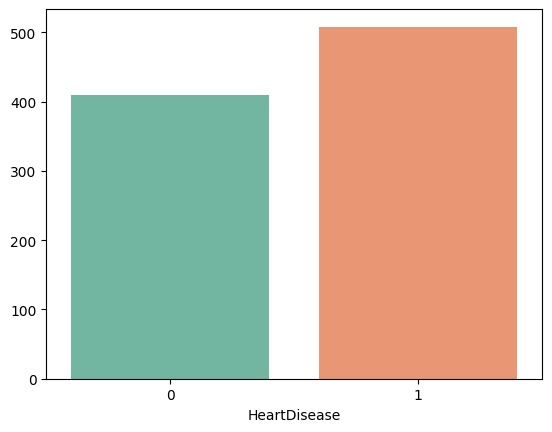

In [46]:
df.head(1)
heart_disease_ditribution  = df['HeartDisease'].value_counts() # Series (Dict) with index and values
display(heart_disease_ditribution)

sns.barplot(x = heart_disease_ditribution.index , y = heart_disease_ditribution.values , palette= 'Set2')

heart_disease_ditribution  = df['HeartDisease'].value_counts(normalize = True)*100 # Series (Dict) with index and values
display(heart_disease_ditribution)


- We will need to predict heart disease based on some columns so we should make sure heart disease are normally distributed

- Why : So model can learn data from both patients equally which have disease and which doesn't have

- For example if out of 918 rows 900 have heart disease , model will not able to predict Non heart disease effectively .
Currently we have 55%/45% distribution , if it was 60/40 or worse , We NOTE it down for later

- Here , we can see data is normally distributed between 0 and 1 , which is a good sign

####
## 2.3 - Distribution of Numeric Columns : Spot Anomalies
####

In [96]:
display(df.head(1))
numeric_colums = ['Age','Cholestrol', 'Cholesterol','FastingBS','MaxHR','Oldpeak','	HeartDisease'] # 7 numeric columns

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0


- We see distribution of only quantative variables generally using histplot with kde=True to detect Anomalies in distribution

- We have 4 quantative variables here : Age , RestingBP , Cholesterol , MaxHR (Fewer unique values with numerical data are also categorical)

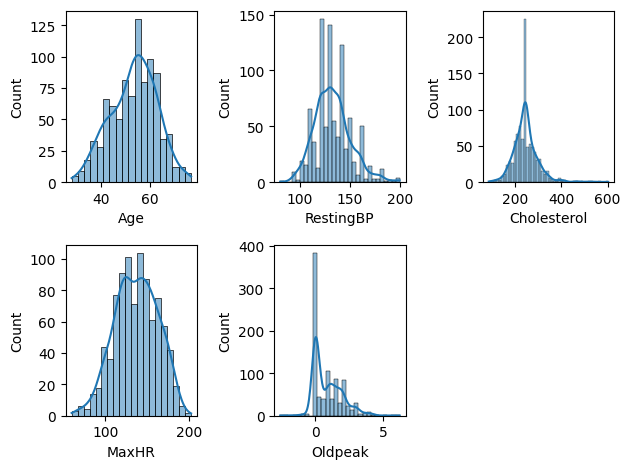

In [104]:
def hist_plot_func(var,subplot_index) :
    plt.subplot(2,3,subplot_index)
    sns.histplot(df[var] , kde=True )

hist_plot_func('Age',1)
hist_plot_func('RestingBP',2)
hist_plot_func('Cholesterol',3)
hist_plot_func('MaxHR',4)
hist_plot_func('Oldpeak',5)
plt.tight_layout() # plt.tight_layout used bcoz some graph label were overlapping each other

In [63]:
display(df.describe())
display(df['Cholesterol'].value_counts()) 

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


Cholesterol
0      172
254     11
220     10
223     10
204      9
      ... 
353      1
278      1
157      1
176      1
131      1
Name: count, Length: 222, dtype: int64

###
#### Anomally :

- Age       : Normally distributed with 28,77 (Age should be 20,80: data is normal w.r.t age , no anomalies there)

- RestingBP : (Min,Max) = (0,200) -> A person cannot have 0 Resting Blood Pressure. Anommaly Detected.. :needs to be fixed as FEW rows have 0 BP

- RestingBP : (0,603) -> Same logic as Resting BP we can see nearly 172 rows have 0 RestingBP which is NOT possible . Anomally Detected ..

- MaxHR     : Normally Distributed (60,202) : Normal Range of Heart Rate ( HR beyong this is suspicious data)

#### Solution :

- We impute/replace those 0 values assuming that no data was collected for that row for that column with average without those rows for both RestingBP and RestingBP

####

### Solving Cholesterol and RestingBP 'Zero' Value Anomally : 
####

In [77]:
df_without_zero_values_RestingBP = df['RestingBP'] !=0 
df_without_zero_values_RestingBP_mean  = round(df[df_without_zero_values_RestingBP]['RestingBP'].mean(),2)
print(f" RestingBP Mean without 0 values : {df_without_zero_values_RestingBP_mean}")

 RestingBP Mean without 0 values : 132.54


In [81]:
df_without_zero_values_Cholesterol = df['Cholesterol'] !=0 
df_without_zero_values_Cholesterol_mean  = round(df[df_without_zero_values_Cholesterol]['Cholesterol'].mean(),2)
print(f" Cholesterol Mean without 0 values : {df_without_zero_values_Cholesterol_mean}")

 Cholesterol Mean without 0 values : 244.64


In [83]:
df['Cholesterol'] = df['Cholesterol'].replace(0,df_without_zero_values_Cholesterol_mean)
df['RestingBP']   = df['RestingBP'].replace(0,df_without_zero_values_RestingBP_mean)

Cholesterol
244.64    172
254.00     11
220.00     10
223.00     10
204.00      9
         ... 
353.00      1
278.00      1
157.00      1
176.00      1
131.00      1
Name: count, Length: 222, dtype: int64

RestingBP
120.0    132
130.0    118
140.0    107
110.0     58
150.0     55
        ... 
101.0      1
117.0      1
192.0      1
129.0      1
164.0      1
Name: count, Length: 67, dtype: int64

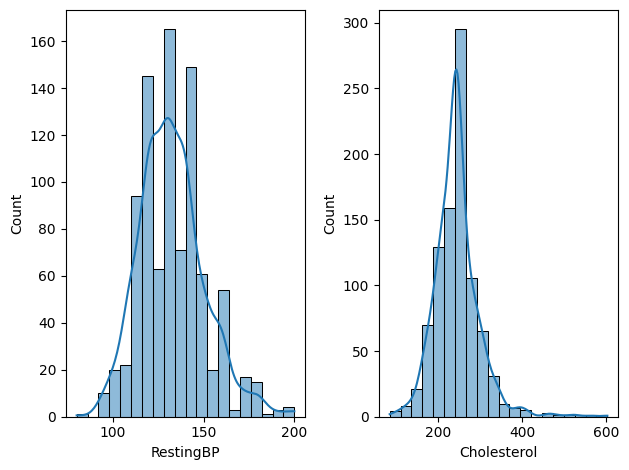

In [91]:
def hist_plot(var , index):
    plt.subplot(1,2,index)
    sns.histplot(df[var],kde=True,bins=20)

hist_plot('RestingBP',1)
hist_plot('Cholesterol',2)
plt.tight_layout()

# to verify mean value was replaced or not 
display(df['Cholesterol'].value_counts())
display(df['RestingBP'].value_counts()) 

###
## 2.4 - Distribution of Categorical Variables : Spot Anomalies
###

In [105]:
display(df.columns)
df.head(2)

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1.0,Flat,1


- Categorical Varaibles here are : Sex / ChestPainType / FastingBS / RestingECG / ExerciseAngina / ST_Slope

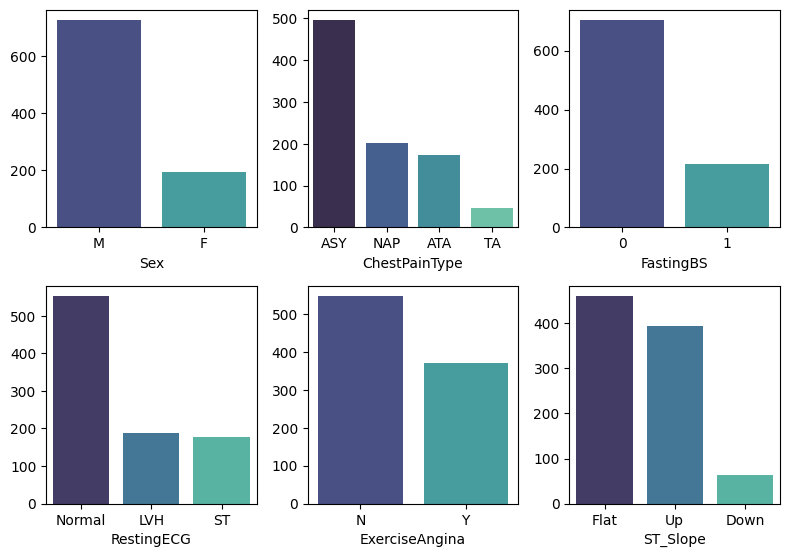

In [112]:
plt.figure(figsize=(8,8))
def bar_chart_plot(var , subplot_index) : 
    plt.subplot(3,3,subplot_index)
    count_series = df[var].value_counts()
    sns.barplot(x = count_series.index , y = count_series.values, palette='mako')

bar_chart_plot('Sex',1)
bar_chart_plot('ChestPainType',2)
bar_chart_plot('FastingBS',3)
bar_chart_plot('RestingECG',4)
bar_chart_plot('ExerciseAngina',5)
bar_chart_plot('ST_Slope',6)

plt.tight_layout()